<a href="https://colab.research.google.com/github/Jonkkeyler333/low_light_enhacement_project/blob/main/LIME/LIME_LOLdatabase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importando Librerias

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage

# Funciones (LIME_Optimization)


In [6]:
def retinexMax(img,gamma,eps):
  img = img.astype(np.float32) / 255.0

  T = np.max(img, axis=2)
  T_refined = np.power(T, gamma)

  R = img / (T_refined[:,:,np.newaxis] + eps)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T_refined, R_uint8


In [7]:
def retinexA(img,a,gamma,eps):
  img = img.astype(np.float32) / 255.0

  T = 1-(1/a)+np.max(img, axis=2)/a
  T = np.clip(T, 0.2, 1)
  T_refined = np.power(T, gamma)

  R = (img-1+a)/ (1-(1/a)+T_refined[:,:,np.newaxis] + eps) + (1-a)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T_refined, R_uint8

In [8]:
def retinexVen(img,vent,gamma,eps):
  img = img.astype(np.float32) / 255.0

  J = np.max(img, axis=2)
  T= np.zeros_like(J)

  T = cv.boxFilter(J,-1,(vent,vent))

  T = np.clip(T, 0.2, 1)
  T_refined = np.power(T, gamma)

  R = img / (T_refined[:,:,np.newaxis] + eps)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T_refined, R_uint8

In [9]:
def gradient_h(img):
  return np.roll(img, -1, axis=1) - img

def gradient_v(img):
  return np.roll(img, -1, axis=0) - img

def divergence_h(img):
  return img - np.roll(img, 1, axis=1)

def divergence_v(img):
  return img - np.roll(img, 1, axis=0)

def shrinkage(x, kappa):
  return np.sign(x) * np.maximum(np.abs(x) - kappa, 0)

In [10]:
def exact_sol(img,alpha,mu,rho,gamma,eps,max_iter,delta):
  img = img.astype(np.float32) / 255.0
  T_hat = np.max(img, axis=2)
  h, w = T_hat.shape

  Wx = 1 / (np.abs(gradient_h(T_hat)) + eps)
  Wy = 1 / (np.abs(gradient_v(T_hat)) + eps)
  T = T_hat.copy()

  Gx = np.zeros_like(T)
  Gy = np.zeros_like(T)

  Zx = np.zeros_like(T)
  Zy = np.zeros_like(T)
  for i in range(max_iter):
    div = (divergence_h(Gx - Zx / mu) +divergence_v(Gy - Zy / mu))
    numerator =  2 * T_hat + mu * div
    denominator = 2 + mu * 4

    T = numerator / denominator
    Tx = gradient_h(T)
    Ty = gradient_v(T)
    Gx = shrinkage(Tx + Zx / mu,alpha * Wx / mu)
    Gy = shrinkage(Ty + Zy / mu,alpha * Wy / mu)
    Zx = Zx + mu * (Tx - Gx)
    Zy = Zy + mu * (Ty - Gy)
    mu = mu * rho
    if np.sqrt(np.sum((Tx - Gx)**2) +np.sum((Ty - Gy)**2)) <= delta*np.linalg.norm(T_hat):
        break

  T = np.clip(T, 0.3, 1)
  T = np.power(T, gamma)

  R = img / (T[:, :, np.newaxis] + eps)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T, R_uint8

In [11]:
def lime_spedup(img,alpha,gamma,eps):
  img = img.astype(np.float32) / 255.0

  T_hat = np.max(img, axis=2)

  grad_x = gradient_h(T_hat)
  grad_y = gradient_v(T_hat)

  Wx = 1.0 / (np.abs(grad_x) + eps)
  Wy = 1.0 / (np.abs(grad_y) + eps)

  denominator = (1+ alpha * (Wx * (grad_x ** 2) / (np.abs(grad_x) + eps)+Wy * (grad_y ** 2) / (np.abs(grad_y) + eps)))

  T = T_hat / denominator
  T = np.power(T, gamma)
  T = np.clip(T, 0.2, 1)

  R = img / (T[:, :, np.newaxis] + eps)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T, R_uint8

In [12]:
def w_stratIII(T,sigma,eps):
  Gx = gradient_h(T)
  Gy = gradient_v(T)
  mag_h = ndimage.gaussian_filter(np.abs(Gx), sigma=sigma)
  mag_v = ndimage.gaussian_filter(np.abs(Gy), sigma=sigma)
  Wx = mag_h / (mag_h + eps)
  Wy = mag_v / (mag_v + eps)
  return Wx, Wy

In [13]:
def lime_wIII(img,alpha,gamma,sigma,eps):
  img = img.astype(np.float32) / 255.0

  T_hat = np.max(img, axis=2)

  grad_x = gradient_h(T_hat)
  grad_y = gradient_v(T_hat)

  Wx, Wy = w_stratIII(T_hat,sigma,eps)

  denominator = (1+ alpha * (Wx * (grad_x ** 2) / (np.abs(grad_x) + eps)+Wy * (grad_y ** 2) / (np.abs(grad_y) + eps)))

  T = T_hat / denominator
  T = np.power(T, gamma)
  T = np.clip(T, 0.2, 1)

  R = img / (T[:, :, np.newaxis] + eps)
  R = np.clip(R, 0, 1)
  R_uint8 = (R * 255).astype(np.uint8)
  return T, R_uint8

# Metricas PSNR y SSIM

In [14]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 14.7 MB/s eta 0:00:00


In [15]:
from torchmetrics.functional.image import peak_signal_noise_ratio as psnr
from torchmetrics.functional.image import structural_similarity_index_measure as ssim
import torch

In [16]:
preds = torch.rand([3, 3, 256, 256])
print(psnr(preds, preds,data_range=255))
print(ssim(preds, preds))

tensor(inf)
tensor(1.)


# Imagenes del LOLdataset

In [17]:
a = 0.95
vent = 15
alpha = 0.15
mu = 0.2
rho = 1.5
gamma = 0.8
eps = 1e-6
sigma = 3
max_iter = 30
delta = 1e-5
vectR1p = []
vectR2p = []
vectR3p = []
vectRexp = []
vectRfap = []
vectRw3p = []
vectR1s = []
vectR2s = []
vectR3s = []
vectRexs = []
vectRfaps = []
vectRw3s = []

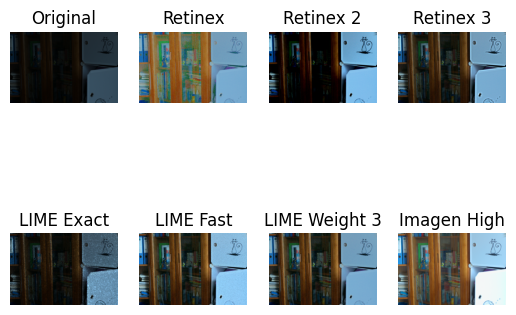

In [19]:
image = cv.imread('/content/sample_data/low/1.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/1.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [20]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(15.2203)
ssim: tensor(0.5535)
Retinex 2
psnr: tensor(11.5207)
ssim: tensor(0.3374)
Retinex 3
psnr: tensor(13.4835)
ssim: tensor(0.5925)
LIME Exact
psnr: tensor(9.4212)
ssim: tensor(0.1869)
LIME Fast
psnr: tensor(16.3472)
ssim: tensor(0.5245)
LIME Weight
psnr: tensor(14.6635)
ssim: tensor(0.6474)


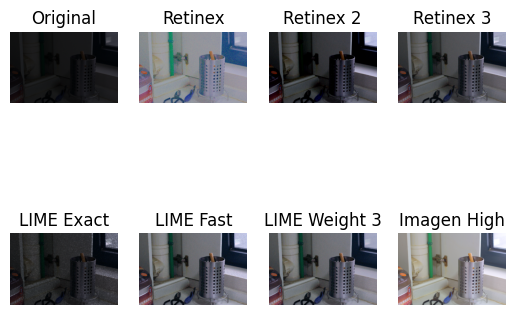

In [21]:
image = cv.imread('/content/sample_data/low/111.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/111.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [22]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(18.7194)
ssim: tensor(0.4802)
Retinex 2
psnr: tensor(7.7742)
ssim: tensor(0.3013)
Retinex 3
psnr: tensor(10.0087)
ssim: tensor(0.5135)
LIME Exact
psnr: tensor(6.8889)
ssim: tensor(0.1197)
LIME Fast
psnr: tensor(13.1337)
ssim: tensor(0.5221)
LIME Weight
psnr: tensor(12.9245)
ssim: tensor(0.5388)


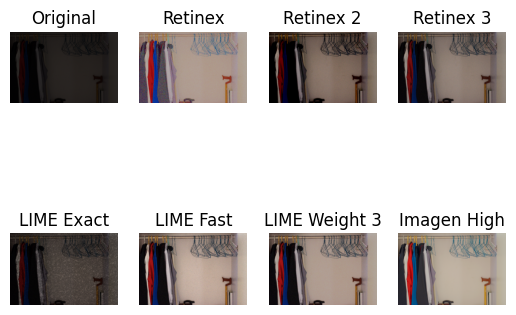

In [23]:
image = cv.imread('/content/sample_data/low/146.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/146.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [24]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(20.8722)
ssim: tensor(0.6044)
Retinex 2
psnr: tensor(11.3884)
ssim: tensor(0.4513)
Retinex 3
psnr: tensor(14.0091)
ssim: tensor(0.6213)
LIME Exact
psnr: tensor(8.5281)
ssim: tensor(0.1498)
LIME Fast
psnr: tensor(20.1469)
ssim: tensor(0.5787)
LIME Weight
psnr: tensor(19.5775)
ssim: tensor(0.6482)


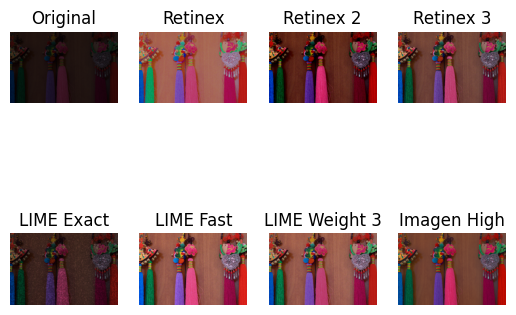

In [25]:
image = cv.imread('/content/sample_data/low/179.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/179.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [26]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(15.7818)
ssim: tensor(0.6037)
Retinex 2
psnr: tensor(19.8580)
ssim: tensor(0.5621)
Retinex 3
psnr: tensor(27.1355)
ssim: tensor(0.7399)
LIME Exact
psnr: tensor(15.6522)
ssim: tensor(0.3260)
LIME Fast
psnr: tensor(18.2823)
ssim: tensor(0.6004)
LIME Weight
psnr: tensor(19.5189)
ssim: tensor(0.6329)


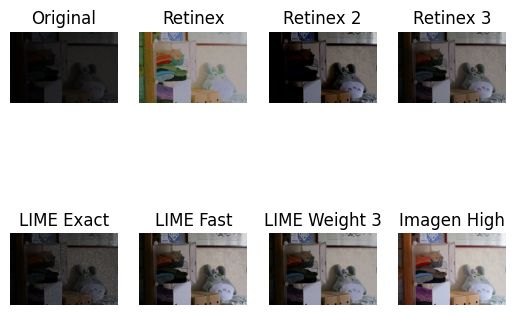

In [27]:
image = cv.imread('/content/sample_data/low/22.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/22.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [28]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(18.0909)
ssim: tensor(0.4751)
Retinex 2
psnr: tensor(9.2556)
ssim: tensor(0.3223)
Retinex 3
psnr: tensor(11.3940)
ssim: tensor(0.5167)
LIME Exact
psnr: tensor(7.5782)
ssim: tensor(0.1243)
LIME Fast
psnr: tensor(15.5003)
ssim: tensor(0.5302)
LIME Weight
psnr: tensor(15.1410)
ssim: tensor(0.5519)


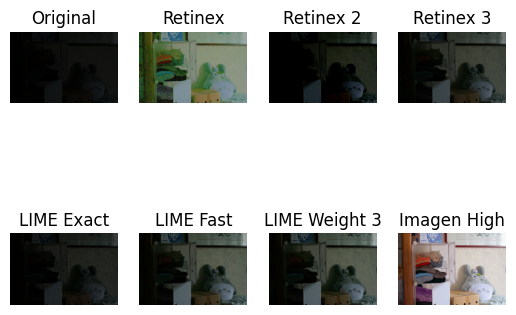

In [29]:
image = cv.imread('/content/sample_data/low/23.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/23.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [30]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(12.3407)
ssim: tensor(0.3014)
Retinex 2
psnr: tensor(5.0022)
ssim: tensor(0.0813)
Retinex 3
psnr: tensor(6.4787)
ssim: tensor(0.2348)
LIME Exact
psnr: tensor(5.2199)
ssim: tensor(0.0678)
LIME Fast
psnr: tensor(7.5603)
ssim: tensor(0.2722)
LIME Weight
psnr: tensor(7.5598)
ssim: tensor(0.2724)


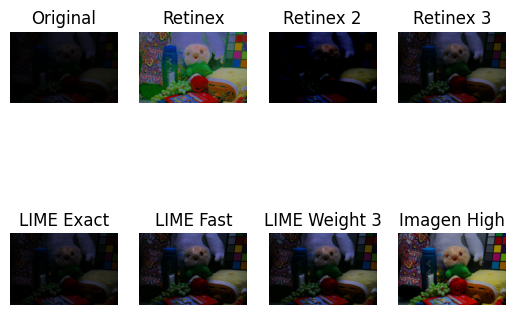

In [31]:
image = cv.imread('/content/sample_data/low/493.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/493.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [32]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(16.9391)
ssim: tensor(0.3837)
Retinex 2
psnr: tensor(11.3676)
ssim: tensor(0.1837)
Retinex 3
psnr: tensor(14.0770)
ssim: tensor(0.4190)
LIME Exact
psnr: tensor(11.8344)
ssim: tensor(0.2160)
LIME Fast
psnr: tensor(16.0134)
ssim: tensor(0.4798)
LIME Weight
psnr: tensor(16.0131)
ssim: tensor(0.4799)


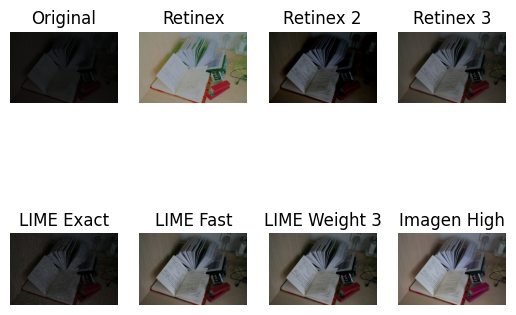

In [33]:
image = cv.imread('/content/sample_data/low/547.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/547.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [34]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(16.9060)
ssim: tensor(0.3679)
Retinex 2
psnr: tensor(10.9917)
ssim: tensor(0.2541)
Retinex 3
psnr: tensor(14.7789)
ssim: tensor(0.5427)
LIME Exact
psnr: tensor(10.5002)
ssim: tensor(0.1765)
LIME Fast
psnr: tensor(19.8168)
ssim: tensor(0.5379)
LIME Weight
psnr: tensor(19.7974)
ssim: tensor(0.5385)


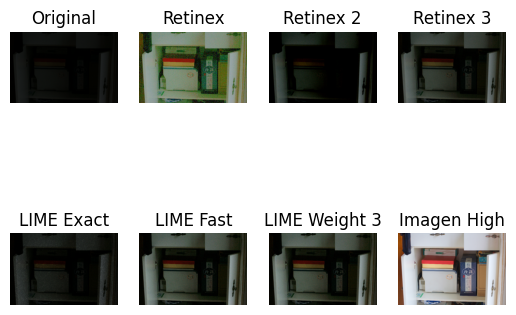

In [35]:
image = cv.imread('/content/sample_data/low/55.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/55.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [36]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(11.9608)
ssim: tensor(0.3146)
Retinex 2
psnr: tensor(4.9096)
ssim: tensor(0.0797)
Retinex 3
psnr: tensor(6.3180)
ssim: tensor(0.2252)
LIME Exact
psnr: tensor(5.0793)
ssim: tensor(0.0616)
LIME Fast
psnr: tensor(7.3542)
ssim: tensor(0.2573)
LIME Weight
psnr: tensor(7.3541)
ssim: tensor(0.2574)


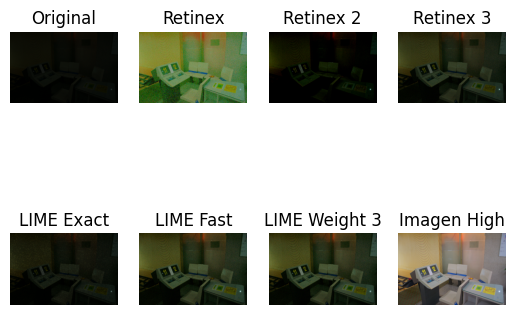

In [37]:
image = cv.imread('/content/sample_data/low/665.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/665.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [38]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(15.5237)
ssim: tensor(0.3062)
Retinex 2
psnr: tensor(6.6876)
ssim: tensor(0.0443)
Retinex 3
psnr: tensor(8.6006)
ssim: tensor(0.2531)
LIME Exact
psnr: tensor(7.3818)
ssim: tensor(0.0950)
LIME Fast
psnr: tensor(9.6405)
ssim: tensor(0.2974)
LIME Weight
psnr: tensor(9.6402)
ssim: tensor(0.2974)


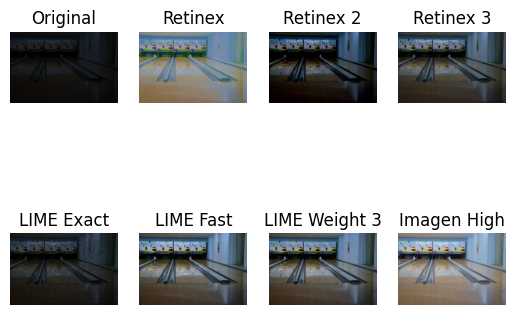

In [39]:
image = cv.imread('/content/sample_data/low/669.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/669.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [40]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(20.0128)
ssim: tensor(0.4285)
Retinex 2
psnr: tensor(8.4882)
ssim: tensor(0.2521)
Retinex 3
psnr: tensor(11.2306)
ssim: tensor(0.4811)
LIME Exact
psnr: tensor(8.0501)
ssim: tensor(0.1363)
LIME Fast
psnr: tensor(14.3510)
ssim: tensor(0.4791)
LIME Weight
psnr: tensor(14.1603)
ssim: tensor(0.4948)


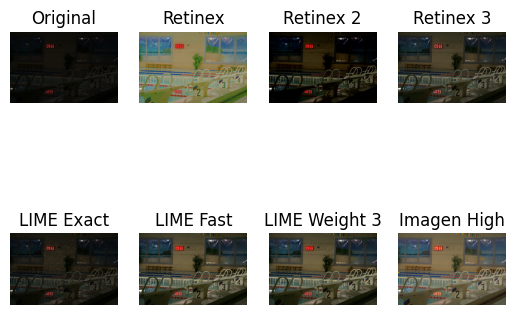

In [41]:
image = cv.imread('/content/sample_data/low/748.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/748.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [42]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(17.7880)
ssim: tensor(0.4295)
Retinex 2
psnr: tensor(10.7655)
ssim: tensor(0.2097)
Retinex 3
psnr: tensor(14.6885)
ssim: tensor(0.5581)
LIME Exact
psnr: tensor(11.3223)
ssim: tensor(0.2182)
LIME Fast
psnr: tensor(18.0451)
ssim: tensor(0.5812)
LIME Weight
psnr: tensor(18.0201)
ssim: tensor(0.5811)


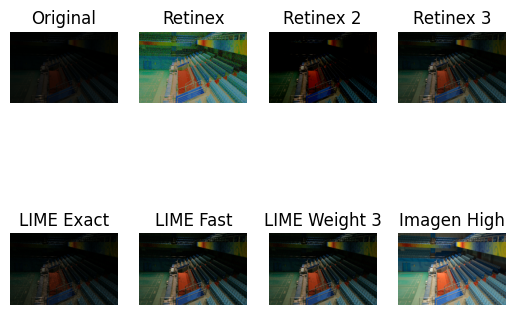

In [43]:
image = cv.imread('/content/sample_data/low/778.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/778.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [44]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(17.7565)
ssim: tensor(0.3930)
Retinex 2
psnr: tensor(9.4074)
ssim: tensor(0.1038)
Retinex 3
psnr: tensor(11.5378)
ssim: tensor(0.3138)
LIME Exact
psnr: tensor(9.7261)
ssim: tensor(0.1223)
LIME Fast
psnr: tensor(13.1150)
ssim: tensor(0.3873)
LIME Weight
psnr: tensor(13.0964)
ssim: tensor(0.3872)


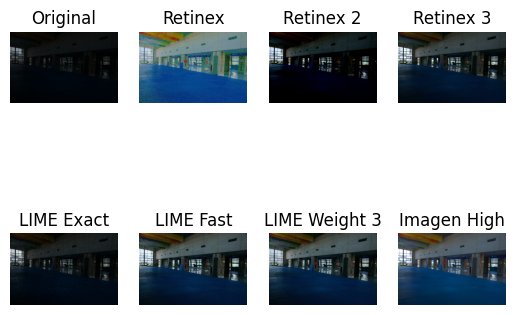

In [45]:
image = cv.imread('/content/sample_data/low/780.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/780.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [46]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(15.8619)
ssim: tensor(0.3734)
Retinex 2
psnr: tensor(13.3281)
ssim: tensor(0.2819)
Retinex 3
psnr: tensor(17.9079)
ssim: tensor(0.5644)
LIME Exact
psnr: tensor(13.8026)
ssim: tensor(0.3033)
LIME Fast
psnr: tensor(21.1354)
ssim: tensor(0.5496)
LIME Weight
psnr: tensor(20.9150)
ssim: tensor(0.5505)


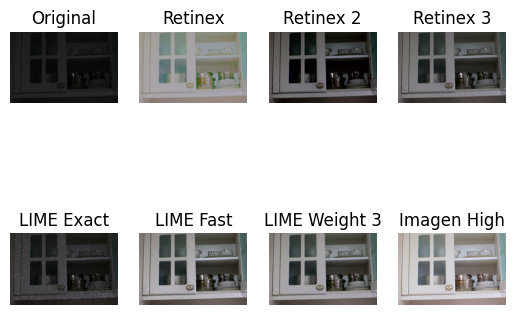

In [47]:
image = cv.imread('/content/sample_data/low/79.png')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.subplot(2,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

_, R1 = retinexMax(image,gamma,eps)

plt.subplot(2,4,2)
plt.imshow(R1)
plt.title("Retinex")
plt.axis("off")

_, R2 = retinexA(image,a,gamma,eps)

plt.subplot(2,4,3)
plt.imshow(R2)
plt.title("Retinex 2")
plt.axis("off")

_, R3 = retinexVen(image,vent,gamma,eps)

plt.subplot(2,4,4)
plt.imshow(R3)
plt.title("Retinex 3")
plt.axis("off")

_, Rex = exact_sol(image,alpha,mu,rho,gamma,eps,max_iter,delta)

plt.subplot(2,4,5)
plt.imshow(Rex)
plt.title("LIME Exact")
plt.axis("off")

_, Rfa = lime_spedup(image,alpha,gamma,eps)

plt.subplot(2,4,6)
plt.imshow(Rfa)
plt.title("LIME Fast")
plt.axis("off")

_, Rw3 = lime_wIII(image,alpha,gamma,sigma,eps)

plt.subplot(2,4,7)
plt.imshow(Rw3)
plt.title("LIME Weight 3")
plt.axis("off")

h_img = cv.imread('/content/sample_data/high/79.png')
h_img = cv.cvtColor(h_img, cv.COLOR_BGR2RGB)

plt.subplot(2,4,8)
plt.imshow(h_img)
plt.title("Imagen High")
plt.axis("off")

plt.show()

In [48]:
pred = torch.tensor(h_img)
target = torch.tensor(R1)
pred = pred.permute(2,0,1).unsqueeze(0).float()
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 1')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR1p.append(psnr(pred, target, data_range=255))
vectR1s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R2)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 2')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR2p.append(psnr(pred, target, data_range=255))
vectR2s.append(ssim(pred, target,data_range=255))

target = torch.tensor(R3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('Retinex 3')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectR3p.append(psnr(pred, target, data_range=255))
vectR3s.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rex)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Exact')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=252))

vectRexp.append(psnr(pred, target, data_range=255))
vectRexs.append(ssim(pred, target,data_range=252))

target = torch.tensor(Rfa)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Fast')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRfap.append(psnr(pred, target, data_range=255))
vectRfaps.append(ssim(pred, target,data_range=255))

target = torch.tensor(Rw3)
target = target.permute(2,0,1).unsqueeze(0).float()
print('LIME Weight')
print('psnr:',psnr(pred, target, data_range=255))
print('ssim:',ssim(pred, target,data_range=255))

vectRw3p.append(psnr(pred, target, data_range=255))
vectRw3s.append(ssim(pred, target,data_range=255))

Retinex 1
psnr: tensor(18.3068)
ssim: tensor(0.4911)
Retinex 2
psnr: tensor(7.7301)
ssim: tensor(0.3591)
Retinex 3
psnr: tensor(9.9519)
ssim: tensor(0.5565)
LIME Exact
psnr: tensor(6.4647)
ssim: tensor(0.1314)
LIME Fast
psnr: tensor(13.7579)
ssim: tensor(0.5655)
LIME Weight
psnr: tensor(13.4796)
ssim: tensor(0.5845)


In [49]:
promR1p = np.mean(vectR1p)
promR2p = np.mean(vectR2p)
promR3p = np.mean(vectR3p)
promRexp = np.mean(vectRexp)
promRfap = np.mean(vectRfap)
promRw3p = np.mean(vectRw3p)
desvR1p = np.std(vectR1p)
desvR2p = np.std(vectR2p)
desvR3p = np.std(vectR3p)
desvRexp = np.std(vectRexp)
desvRfap = np.std(vectRfap)
desvRw3p = np.std(vectRw3p)

promR1s = np.mean(vectR1s)
promR2s = np.mean(vectR2s)
promR3s = np.mean(vectR3s)
promRexs = np.mean(vectRexs)
promRfaps = np.mean(vectRfaps)
promRw3s = np.mean(vectRw3s)
desvR1s = np.std(vectR1s)
desvR2s = np.std(vectR2s)
desvR3s = np.std(vectR3s)
desvRexs = np.std(vectRexs)
desvRfaps = np.std(vectRfaps)
desvRw3s = np.std(vectRw3s)

In [50]:
print('Promedios y Desviaciones Estandar')
print('Retinex 1')
print('psnr:',promR1p,'+-',desvR1p)
print('ssim:',promR1s,'+-',desvR1s)
print('Retinex 2')
print('psnr:',promR2p,'+-',desvR2p)
print('ssim:',promR2s,'+-',desvR2s)
print('Retinex 3')
print('psnr:',promR3p,'+-',desvR3p)
print('ssim:',promR3s,'+-',desvR3s)
print('LIME Exact')
print('psnr:',promRexp,'+-',desvRexp)
print('ssim:',promRexs,'+-',desvRexs)
print('LIME Fast')
print('psnr:',promRfap,'+-',desvRfap)
print('ssim:',promRfaps,'+-',desvRfaps)
print('LIME Weight')
print('psnr:',promRw3p,'+-',desvRw3p)
print('ssim:',promRw3s,'+-',desvRw3s)

Promedios y Desviaciones Estandar
Retinex 1
psnr: 16.8054 +- 2.3915215
ssim: 0.43374857 +- 0.09649304
Retinex 2
psnr: 9.898335 +- 3.5678234
ssim: 0.25494245 +- 0.1398172
Retinex 3
psnr: 12.773376 +- 4.9273148
ssim: 0.47551355 +- 0.14905573
LIME Exact
psnr: 9.163332 +- 2.939496
ssim: 0.16234273 +- 0.07471629
LIME Fast
psnr: 14.94666 +- 4.1790075
ssim: 0.4775494 +- 0.112807065
LIME Weight
psnr: 14.790759 +- 4.1832385
ssim: 0.4975265 +- 0.12859683
